# Capítulo 19: La ecuación de Laplace/Poisson

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/10-laplace.ipynb)

Notebook que acompaña al Capítulo 19 (La ecuación de Laplace/Poisson) de *Introducción al Modelado Continuo*. Sigue el orden del texto: las **superficies mínimas** (la película de jabón sobre un anillo de alambre, cuya linealización es la ecuación de Laplace); el **juego aleatorio** cuyo valor esperado satisface la ecuación de promedios $u(x,y) = \frac14\bigl[u(x+h,y) + u(x-h,y) + u(x,y+h) + u(x,y-h)\bigr]$, que en el límite es $\Delta u = 0$; las **propiedades analíticas** (principio del máximo, propiedad del valor medio); la **solución fundamental** $\Phi(\mathbf x) = -\frac{1}{2\pi}\ln|\mathbf x|$, la superposición y la convolución $u = \Phi * f$; y la resolución por **series de Fourier en un rectángulo**.

En cada caso verificamos numéricamente lo que el texto afirma: que la superficie armónica tiene menos área que otra con el mismo borde, que el juego (simulado por Monte Carlo) da la misma función que el esquema de cinco puntos `imc.numerico.poisson_cinco_puntos`, que el máximo y el mínimo de una función armónica están en el borde, que el promedio sobre círculos es constante e igual al valor en el centro, que $\Phi$ es armónica fuera del origen y su flujo a través de cualquier círculo es $-1$, y que la serie de Fourier truncada coincide con la solución en diferencias finitas.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import LightSource
from scipy.integrate import quad
from scipy.signal import fftconvolve
from imc import estilo, numerico
from imc.estilo import COLORES, CICLO

estilo.activar(fuente=14)   # las figuras de un panel van a 0.4-0.6\textwidth (~6-9 cm): fuente grande para que se lean impresas
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/


def fuente(F):
    '''Contexto con fuente F en ejes y ticks (leyenda F-2) para las figuras de varios paneles (van a 0.8-0.95\textwidth).'''
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 2, "lines.linewidth": 2.0})


def mapa(ax, x, y, U, vmin=None, vmax=None, niveles=8, etiqueta=None, suave=True):
    '''Mapa de color de U(x, y) (viridis, escala [vmin, vmax]) con `niveles` contornos blancos (0: sin contornos); devuelve el mappable para la colorbar.'''
    vmin = U.min() if vmin is None else vmin; vmax = U.max() if vmax is None else vmax
    im = ax.pcolormesh(x, y, U, cmap="viridis", vmin=vmin, vmax=vmax, shading="gouraud" if suave else "nearest", rasterized=True)
    if niveles: ax.contour(x, y, U, levels=np.linspace(vmin, vmax, niveles + 2)[1:-1], colors="white", linewidths=0.7, alpha=0.75)
    ax.set_aspect("equal"); ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
    if etiqueta: ax.set_title(etiqueta)
    return im


def laplaciano_h(U, h):
    '''Laplaciano de cinco puntos de U en los nodos interiores (array (n-1) x (n-1)).'''
    return (U[2:, 1:-1] + U[:-2, 1:-1] + U[1:-1, 2:] + U[1:-1, :-2] - 4 * U[1:-1, 1:-1]) / h ** 2

## 19.1 Motivación: superficies mínimas

La película de jabón sobre un anillo de alambre es el gráfico $z = u(x,y)$ sobre el disco $D$ que minimiza el área $\mathcal A(u) = \int_D\sqrt{1 + |\nabla u|^2}\,dA$ entre las superficies con el mismo borde $u = g$ en $\partial D$. Si $|\nabla u|$ es chico, $\mathcal A(u) \simeq \text{área}(D) + \mathcal J(u)$ con $\mathcal J(u) = \frac12\int_D|\nabla u|^2\,dA$ (la integral de Dirichlet), y el mínimo de $\mathcal J$ es la solución de $\Delta u = 0$ con $u = g$ en el borde.

**Figuras `sup-min1` y `sup-min2`**: un alambre no plano, $g(\theta) = 0.3\cos 2\theta$ sobre el círculo unitario. La solución de Laplace con ese dato es $u(x,y) = 0.3\,(x^2 - y^2)$ (a la derecha: es $0.3\,r^2\cos2\theta$, que en $r = 1$ vale $g$ y es armónica). A la izquierda, otra superficie con el mismo borde, a la que le agregamos ondulaciones interiores que se anulan en $r = 1$. Calculamos las dos áreas (y las dos integrales de Dirichlet) integrando en coordenadas polares: la superficie armónica tiene menos área. (Es el mínimo del problema linealizado; la verdadera superficie mínima difiere poco porque acá $|\nabla u| \le 0.6$.) Las dos figuras comparten el punto de vista y la escala de color; la corrección al texto es que en la versión anterior ambas se veían iguales.

In [2]:
r_p = np.linspace(0, 1, 201); th_p = np.linspace(0, 2 * np.pi, 361)
R, TH = np.meshgrid(r_p, th_p, indexing="ij"); Xp, Yp = R * np.cos(TH), R * np.sin(TH)
u_arm = 0.3 * R ** 2 * np.cos(2 * TH)                                         # armónica: 0.3 (x^2 - y^2)
u_arr = u_arm + 0.25 * (1 - R ** 2) * np.sin(2.5 * np.pi * Xp) * np.sin(2.5 * np.pi * Yp)   # ondulaciones suaves que se anulan en r = 1

def grad2_polar(U):
    '''|grad U|^2 = U_r^2 + U_theta^2 / r^2 para U dada en la grilla polar (r, theta).'''
    U_r = np.gradient(U, r_p, axis=0); U_th = np.gradient(U, th_p, axis=1)
    return U_r ** 2 + np.divide(U_th ** 2, R ** 2, out=np.zeros_like(U), where=R > 0)

def area_y_dirichlet(U):
    '''(área del gráfico, integral de Dirichlet) de U dada en la grilla polar: integrales en r dr dtheta con la regla del trapecio.'''
    grad2 = grad2_polar(U)
    integrar = lambda F: np.trapezoid(np.trapezoid(F * R, th_p, axis=1), r_p)
    return integrar(np.sqrt(1 + grad2)), 0.5 * integrar(grad2)

print(f"área del disco D: {np.pi:.4f}")
for nombre, U in [("arrugada", u_arr), ("armónica", u_arm)]:
    A, J = area_y_dirichlet(U)
    print(f"superficie {nombre}: área A = {A:.4f},  J = (1/2) int |grad u|^2 = {J:.4f},  pi + J = {np.pi + J:.4f};  máx |grad u| = {np.sqrt(grad2_polar(U)).max():.2f}")
hx = 1e-3   # Laplaciano de 0.3 (x^2 - y^2) en un punto cualquiera
lap = lambda F, x, y: (F(x + hx, y) + F(x - hx, y) + F(x, y + hx) + F(x, y - hx) - 4 * F(x, y)) / hx ** 2
print(f"Laplaciano numérico de 0.3(x^2 - y^2) en (0.4, -0.2): {lap(lambda x, y: 0.3 * (x ** 2 - y ** 2), 0.4, -0.2):.1e}")

área del disco D: 3.1416
superficie arrugada: área A = 4.2026,  J = (1/2) int |grad u|^2 = 1.3393,  pi + J = 4.4809;  máx |grad u| = 1.89
superficie armónica: área A = 3.4093,  J = (1/2) int |grad u|^2 = 0.2827,  pi + J = 3.4243;  máx |grad u| = 0.60
Laplaciano numérico de 0.3(x^2 - y^2) en (0.4, -0.2): 0.0e+00


Las dos figuras, con el mismo punto de vista y la misma escala de color (excepción al criterio de no usar superficies 3D: acá lo que se quiere mostrar *es* una superficie). El alambre $u = g$ va en negro y el disco $D$ debajo.

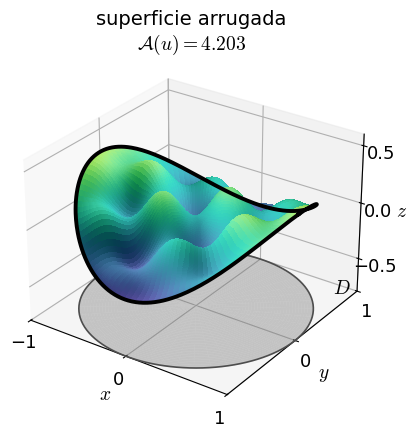

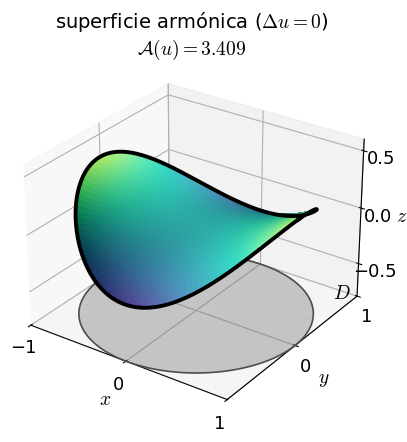

In [3]:
norm = plt.Normalize(-0.45, 0.45); z0 = -0.8
for nombre, U in [("sup-min1", u_arr), ("sup-min2", u_arm)]:
    A, J = area_y_dirichlet(U)
    fig = plt.figure(figsize=(4.6, 4.6))
    ax = fig.add_subplot(projection="3d", computed_zorder=False)
    ax.plot_surface(Xp, Yp, np.full_like(Xp, z0), color="0.75", alpha=0.35, linewidth=0, zorder=0)              # el disco D
    ax.plot(np.cos(th_p), np.sin(th_p), z0, color="0.3", lw=1.2, zorder=1)
    colores = LightSource(azdeg=300, altdeg=60).shade_rgb(plt.cm.viridis(norm(U))[..., :3], U, blend_mode="soft", vert_exag=40)   # relieve suave sobre el colormap
    ax.plot_surface(Xp, Yp, U, facecolors=colores, rstride=2, cstride=3, linewidth=0, antialiased=False, shade=False, zorder=2)
    ax.plot(np.cos(th_p), np.sin(th_p), 0.3 * np.cos(2 * th_p), color="black", lw=2.8, zorder=4)              # el alambre u = g
    ax.view_init(elev=28, azim=-55); ax.set_zlim(z0, 0.6); ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_xticks([-1, 0, 1]); ax.set_yticks([0, 1]); ax.set_zticks([-0.5, 0, 0.5]); ax.set_box_aspect((1, 1, 0.75), zoom=1.05)
    ax.set_xlabel("$x$", labelpad=-2); ax.set_ylabel("$y$", labelpad=-2); ax.set_zlabel("$z$", labelpad=-4); ax.tick_params(pad=-1)
    ax.text(0.85, 0.85, z0, "$D$", fontsize=14)
    ax.set_title(("superficie arrugada" if nombre == "sup-min1" else "superficie armónica ($\\Delta u = 0$)") + f"\n$\\mathcal{{A}}(u) = {A:.3f}$", fontsize=14, pad=-6)
    if GUARDAR: estilo.guardar(fig, nombre)

## 19.2 Juegos aleatorios y valor esperado

El juego del texto: en la grilla de paso $h = 1/n$ del cuadrado $Q = [0,1]^2$, el jugador salta a uno de los cuatro vecinos con probabilidad $1/4$ hasta llegar al borde, donde cobra $g$. El valor esperado $u(x,y)$ del pago cumple $u = g$ en $\partial Q$ y, en cada punto interior, $u(x,y) = \frac14\bigl[u(x+h,y) + u(x-h,y) + u(x,y+h) + u(x,y-h)\bigr]$. **Figura `juego`**: el esquema (rehecho en matplotlib).

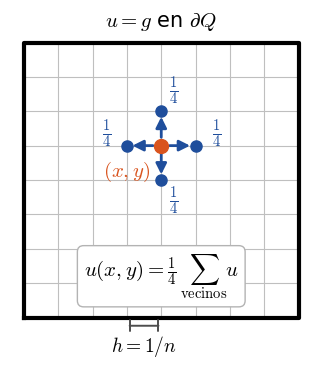

In [4]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
n_esq = 8; hh = 1 / n_esq
for k in range(1, n_esq):
    ax.plot([0, 1], [k * hh, k * hh], color="0.75", lw=0.8); ax.plot([k * hh, k * hh], [0, 1], color="0.75", lw=0.8)
ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color="black", lw=3)
xc, yc = 4 * hh, 5 * hh
for dx_, dy_ in [(hh, 0), (-hh, 0), (0, hh), (0, -hh)]:
    ax.annotate("", (xc + dx_, yc + dy_), (xc, yc), arrowprops=dict(arrowstyle="-|>", color=COLORES["traj"], lw=2, mutation_scale=16, shrinkA=6, shrinkB=4))
    ax.plot(xc + dx_, yc + dy_, "o", color=COLORES["traj"], ms=8)
    ax.text(xc + 1.6 * dx_ + (0.045 if dy_ else 0), yc + 1.6 * dy_ + (0.045 if dx_ else 0), r"$\frac{1}{4}$", fontsize=15, ha="center", va="center", color=COLORES["traj"])
ax.plot(xc, yc, "o", color=COLORES["modelo"], ms=10, zorder=5)
ax.text(xc - 0.04, yc - 0.05, "$(x, y)$", fontsize=15, color=COLORES["modelo"], ha="right", va="top")
ax.text(0.5, 0.15, r"$u(x,y) = \frac{1}{4}\,\sum_{\mathrm{vecinos}} u$", fontsize=15, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7"))
ax.text(0.5, 1.035, r"$u = g$ en $\partial Q$", fontsize=15, ha="center", va="bottom")
ax.annotate("", (3 * hh, -0.03), (4 * hh, -0.03), arrowprops=dict(arrowstyle="|-|", color="0.3", lw=1.4, mutation_scale=4))
ax.text(3.5 * hh, -0.06, "$h = 1/n$", fontsize=14, ha="center", va="top")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.14, 1.12); ax.set_aspect("equal"); ax.axis("off")
if GUARDAR: estilo.guardar(fig, "juego")

**Monte Carlo contra cinco puntos.** Tomamos $n = 20$ y el pago $g(x,y) = \sin 2\pi x + \tfrac12\cos 3\pi y$ en el borde (máximo $3/2$ en $(1/4, 0)$, mínimo $-3/2$ en $(3/4, 1)$). Estimamos $u$ en cada uno de los $19^2$ puntos interiores promediando el pago de $M = 400$ partidas (`montecarlo`: todas las partidas se simulan a la vez con `numpy`), y resolvemos exactamente la ecuación de promedios con `numerico.poisson_cinco_puntos` (con $f = 0$ es exactamente el sistema lineal $u_{ij} = \frac14\sum u_{\text{vecinos}}$). La diferencia entre ambas es el error estadístico, del orden de $\sigma/\sqrt M$ donde $\sigma \lesssim 1$ es la desviación del pago.

In [5]:
def g_borde(x, y):
    '''Pago g(x, y) = sin(2 pi x) + cos(3 pi y)/2 (se usa sólo en el borde del cuadrado).'''
    return np.sin(2 * np.pi * x) + 0.5 * np.cos(3 * np.pi * y)

def montecarlo(G, M, rng):
    '''Valor esperado del juego en cada nodo interior de la grilla (n+1) x (n+1) (G tiene el pago en el borde), promediando M partidas por nodo.
    Devuelve (u, número máximo de pasos). u[i, j] corresponde a (x_j, y_i).'''
    n = G.shape[0] - 1
    I, J = np.meshgrid(np.arange(1, n), np.arange(1, n), indexing="ij")
    i = np.repeat(I.ravel(), M); j = np.repeat(J.ravel(), M)          # una partida por fila: (n-1)^2 M jugadores a la vez
    pago = np.zeros(i.size); activo = np.ones(i.size, dtype=bool); pasos = 0
    while activo.any():
        k = np.flatnonzero(activo); d = rng.integers(4, size=k.size)
        i[k] += (d == 0).astype(int) - (d == 1); j[k] += (d == 2).astype(int) - (d == 3)
        llego = (i[k] == 0) | (i[k] == n) | (j[k] == 0) | (j[k] == n)
        pago[k[llego]] = G[i[k[llego]], j[k[llego]]]; activo[k[llego]] = False; pasos += 1
    u = G.copy(); u[1:-1, 1:-1] = pago.reshape(n - 1, n - 1, M).mean(axis=-1)
    return u, pasos

def una_partida(n, i0, j0, rng):
    '''Trayectoria (lista de (i, j)) de una partida desde el nodo (i0, j0) hasta el borde.'''
    i, j = i0, j0; tray = [(i, j)]
    while 0 < i < n and 0 < j < n:
        d = rng.integers(4); i += int(d == 0) - int(d == 1); j += int(d == 2) - int(d == 3); tray.append((i, j))
    return np.array(tray)

rng = np.random.default_rng(1)
n_j, M_j = 20, 400
xj = np.linspace(0, 1, n_j + 1); Xj, Yj = np.meshgrid(xj, xj)
G = g_borde(Xj, Yj); G[1:-1, 1:-1] = 0.0                              # sólo importa el borde
u_mc, pasos_max = montecarlo(G, M_j, rng)
u_5p = numerico.poisson_cinco_puntos(0.0, G, 1 / n_j)
tray = max((una_partida(n_j, n_j // 2, n_j // 2, rng) for _ in range(10)), key=len)   # la más larga de diez, para que se vea el paseo
print(f"n = {n_j}: {(n_j - 1) ** 2} nodos interiores x {M_j} partidas = {(n_j - 1) ** 2 * M_j} jugadores; la partida más larga duró {pasos_max} pasos; la de la figura, {len(tray) - 1}")
print(f"cinco puntos: u en el centro = {u_5p[n_j // 2, n_j // 2]:.4f}; residuo máximo de u_ij - (1/4) sum vecinos: {np.abs(u_5p[1:-1, 1:-1] - (u_5p[2:, 1:-1] + u_5p[:-2, 1:-1] + u_5p[1:-1, 2:] + u_5p[1:-1, :-2]) / 4).max():.1e}")
print(f"Monte Carlo: u en el centro = {u_mc[n_j // 2, n_j // 2]:.4f}; error máximo respecto de cinco puntos {np.abs(u_mc - u_5p).max():.3f}, error cuadrático medio {np.sqrt(np.mean((u_mc - u_5p) ** 2)):.3f}  (referencia sigma/sqrt(M) con sigma = 1: {1 / np.sqrt(M_j):.3f})")

n = 20: 361 nodos interiores x 400 partidas = 144400 jugadores; la partida más larga duró 874 pasos; la de la figura, 230
cinco puntos: u en el centro = -0.0000; residuo máximo de u_ij - (1/4) sum vecinos: 4.4e-16
Monte Carlo: u en el centro = 0.0009; error máximo respecto de cinco puntos 0.106, error cuadrático medio 0.028  (referencia sigma/sqrt(M) con sigma = 1: 0.050)


*Figura nueva `juego-montecarlo`*: (a) una partida desde el centro; (b) $u$ por Monte Carlo; (c) $u$ por cinco puntos, misma escala de color. Las dos son la misma función salvo el ruido estadístico (error cuadrático medio $\simeq 0.03$; con $4M$ partidas se reduce a la mitad).

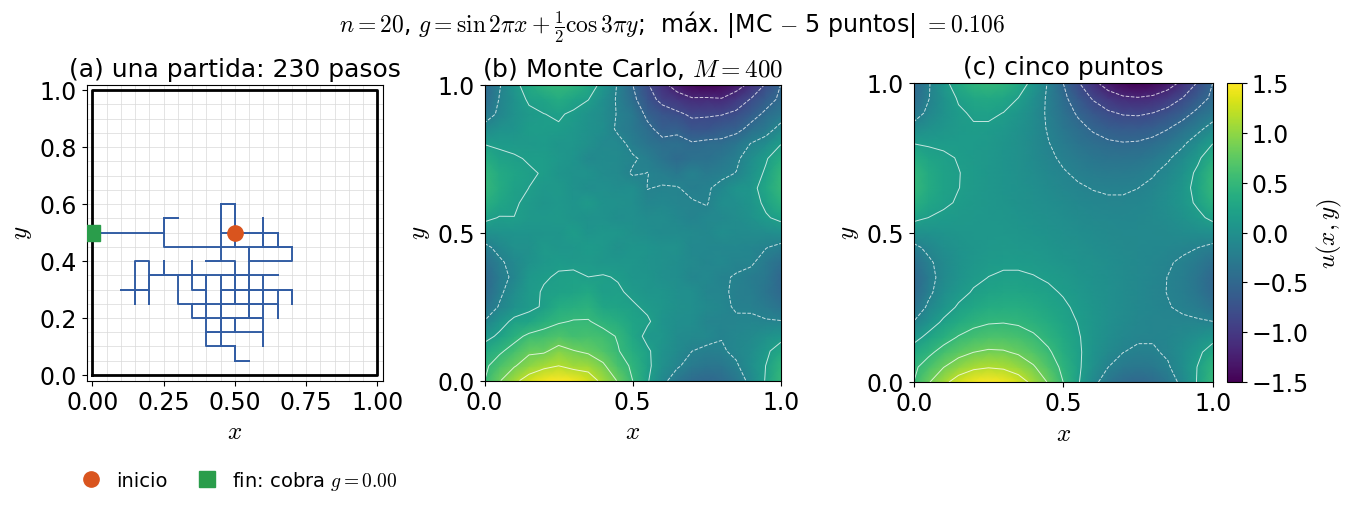

In [6]:
with fuente(18):
    fig, axs = plt.subplots(1, 3, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1, 1, 1.22]))
    ax = axs[0]
    for k in range(1, n_j):
        ax.axhline(k / n_j, color="0.85", lw=0.5); ax.axvline(k / n_j, color="0.85", lw=0.5)
    ax.plot(tray[:, 1] / n_j, tray[:, 0] / n_j, color=COLORES["traj"], lw=1.4, alpha=0.9)
    ax.plot(0.5, 0.5, "o", color=COLORES["modelo"], ms=11, zorder=5, label="inicio")
    ax.plot(tray[-1, 1] / n_j, tray[-1, 0] / n_j, "s", color=COLORES["nul_p"], ms=11, zorder=5, label=f"fin: cobra $g = {G[tray[-1, 0], tray[-1, 1]]:.2f}$".replace("-0.00", "0.00"))
    ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color="black", lw=2); ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.set_aspect("equal")
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_title(f"(a) una partida: {len(tray) - 1} pasos"); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.24), ncol=2, fontsize=14, handletextpad=0.3, columnspacing=1.0)
    vmin, vmax = -1.5, 1.5
    mapa(axs[1], xj, xj, u_mc, vmin, vmax, etiqueta=f"(b) Monte Carlo, $M = {M_j}$")
    im = mapa(axs[2], xj, xj, u_5p, vmin, vmax, etiqueta="(c) cinco puntos")
    for ax in axs[1:]: ax.set_xticks([0, 0.5, 1]); ax.set_yticks([0, 0.5, 1])
    cb = fig.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04); cb.set_label("$u(x, y)$")
    fig.suptitle(f"$n = {n_j}$, $g = \\sin 2\\pi x + \\frac{{1}}{{2}}\\cos 3\\pi y$;  máx. |MC $-$ 5 puntos| $= {np.abs(u_mc - u_5p).max():.3f}$", fontsize=17, y=0.98)
    fig.subplots_adjust(left=0.05, right=0.94, top=0.82, bottom=0.17, wspace=0.32)
    if GUARDAR: estilo.guardar(fig, "juego-montecarlo")

## 19.3 Propiedades analíticas

**Principio del máximo.** Si $\Delta u \ge 0$ en $\Omega$ acotado, $\max_{\overline\Omega} u = \max_{\partial\Omega} u$ (y para $\Delta u \le 0$, el mínimo). *Figura nueva `principio-maximo`* (opcional, en la Subsección "Principio del máximo"): la solución armónica del cuadrado con el mismo dato $g$ del juego, ahora en una grilla fina ($n = 100$), con el máximo y el mínimo marcados: están en el borde, en $(1/4, 0)$ y $(3/4, 1)$, donde $g$ los alcanza. Verificamos que ningún valor interior supera a $\max g$ ni baja de $\min g$, y también la versión discreta del principio de comparación: al agregar una fuente $f \ge 0$ constante (que en el juego es un cobro en cada paso) la solución de $-\Delta u = f$ sube en todo el cuadrado y su mínimo sigue en el borde, pero el máximo puede pasar al interior (con $f = 4$ todavía no; con $f = 20$ sí): el principio del máximo vale para $f \le 0$.

máximo 1.5000 en (x, y) = (0.25, 0.00), en el borde: True;  mínimo -1.5000 en (0.75, 1.00), en el borde: True
máximo interior 1.4227 < máx g = 1.5000;  mínimo interior -1.4227 > mín g = -1.5000
con fuente f = 4 (>= 0): u_f >= u en todo el cuadrado: True; máximo 1.500 en (0.25, 0.00), en el borde: True (el principio del máximo pide f <= 0); mínimo -1.500 en el borde: True
con fuente f = 20 (>= 0): u_f >= u en todo el cuadrado: True; máximo 1.513 en (0.45, 0.42), en el borde: False (el principio del máximo pide f <= 0); mínimo -1.500 en el borde: True


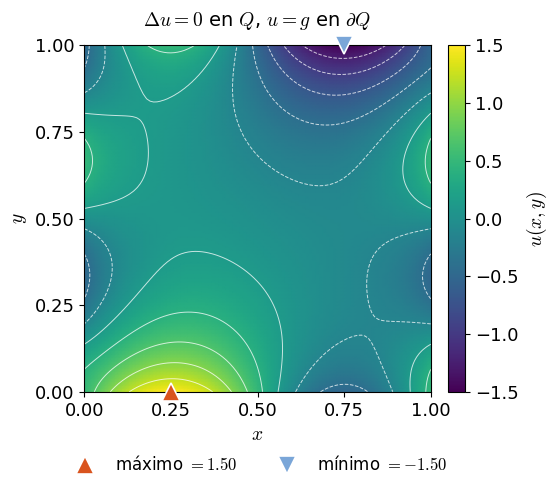

In [7]:
n_f = 100; h_f = 1 / n_f
xf = np.linspace(0, 1, n_f + 1); Xf, Yf = np.meshgrid(xf, xf)
Gf = g_borde(Xf, Yf); Gf[1:-1, 1:-1] = 0.0
u_f = numerico.poisson_cinco_puntos(0.0, Gf, h_f)
borde = np.zeros_like(u_f, dtype=bool); borde[[0, -1], :] = True; borde[:, [0, -1]] = True
imax = np.unravel_index(u_f.argmax(), u_f.shape); imin = np.unravel_index(u_f.argmin(), u_f.shape)
print(f"máximo {u_f.max():.4f} en (x, y) = ({xf[imax[1]]:.2f}, {xf[imax[0]]:.2f}), en el borde: {borde[imax]};  mínimo {u_f.min():.4f} en ({xf[imin[1]]:.2f}, {xf[imin[0]]:.2f}), en el borde: {borde[imin]}")
print(f"máximo interior {u_f[~borde].max():.4f} < máx g = {Gf[borde].max():.4f};  mínimo interior {u_f[~borde].min():.4f} > mín g = {Gf[borde].min():.4f}")
for f_c in [4.0, 20.0]:
    u_fuente = numerico.poisson_cinco_puntos(f_c, Gf, h_f)
    jmax = np.unravel_index(u_fuente.argmax(), u_f.shape)
    print(f"con fuente f = {f_c:g} (>= 0): u_f >= u en todo el cuadrado: {np.all(u_fuente >= u_f - 1e-12)}; máximo {u_fuente.max():.3f} en ({xf[jmax[1]]:.2f}, {xf[jmax[0]]:.2f}), en el borde: {borde[jmax]} (el principio del máximo pide f <= 0); mínimo {u_fuente.min():.3f} en el borde: {borde[np.unravel_index(u_fuente.argmin(), u_f.shape)]}")

fig, ax = plt.subplots(figsize=(5.6, 4.5))
im = mapa(ax, xf, xf, u_f, -1.5, 1.5, niveles=10)
ax.plot(xf[imax[1]], xf[imax[0]], "^", color=COLORES["modelo"], ms=13, mec="white", mew=1.2, label=f"máximo $= {u_f.max():.2f}$", clip_on=False, zorder=6)
ax.plot(xf[imin[1]], xf[imin[0]], "v", color=COLORES["traj2"], ms=13, mec="white", mew=1.2, label=f"mínimo $= {u_f.min():.2f}$", clip_on=False, zorder=6)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1]); ax.set_yticks([0, 0.25, 0.5, 0.75, 1]); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=12)
ax.set_title(r"$\Delta u = 0$ en $Q$, $u = g$ en $\partial Q$", fontsize=14, pad=14)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label("$u(x, y)$")
if GUARDAR: estilo.guardar(fig, "principio-maximo")

**Propiedad del valor medio.** Si $u$ es armónica, $u(\mathbf x_0) = \frac{1}{|\partial B_r|}\int_{\partial B_r(\mathbf x_0)}u\,dS = \frac{1}{|B_r|}\int_{B_r(\mathbf x_0)}u\,d\mathbf x$ para toda bola contenida en $\Omega$. *Figura nueva `valor-medio`* (en la Subsección "La propiedad del valor medio"): (a) la función armónica $u = \mathrm{Re}(z^3) = x^3 - 3xy^2$, un punto $\mathbf x_0$ y círculos de radios $r = 0.1, \dots, 0.6$; (b) el promedio de $u$ sobre cada círculo (y sobre cada disco) en función de $r$: constante, igual a $u(\mathbf x_0)$. Para una función no armónica, $v = x^2 + y^2$ ($\Delta v = 4 > 0$), el promedio sobre el círculo es $v(\mathbf x_0) + r^2$: crece con $r$ (una subarmónica está por debajo de sus promedios, que es lo que dice el principio del máximo). Los promedios se calculan con la regla del trapecio en $\theta$ (y en $r$ para el disco).

u = x^3 - 3xy^2, x0 = (0.35, 0.25): u(x0) = -0.02275
   promedios sobre los círculos: [-0.02275 -0.02275 -0.02275 -0.02275 -0.02275 -0.02275]  (máx. desviación 3.5e-17)
   promedios sobre los discos:   [-0.02275 -0.02275 -0.02275 -0.02275 -0.02275 -0.02275]  (máx. desviación 2.4e-17)
v = x^2 + y^2: v(x0) = 0.1850; promedios sobre círculos [0.195 0.225 0.275 0.345 0.435 0.545] = v(x0) + r^2 (máx. desviación 5.6e-17); sobre discos, v(x0) + r^2/2: 2.0e-06


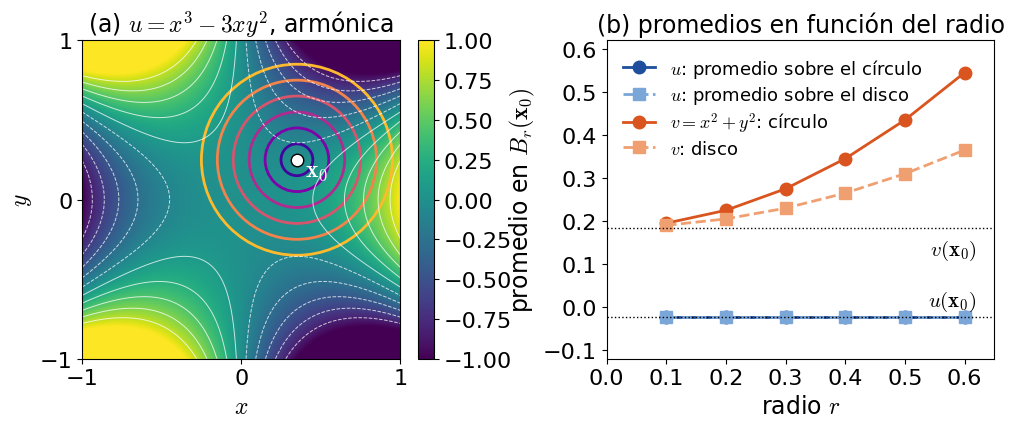

In [8]:
u_h = lambda x, y: x ** 3 - 3 * x * y ** 2          # Re(z^3), armónica
v_nh = lambda x, y: x ** 2 + y ** 2                  # Laplaciano 4
x0, y0 = 0.35, 0.25
radios = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
th = np.linspace(0, 2 * np.pi, 721)

def promedio_circulo(F, r):
    return np.trapezoid(F(x0 + r * np.cos(th), y0 + r * np.sin(th)), th) / (2 * np.pi)

def promedio_disco(F, r):
    rr = np.linspace(0, r, 301)
    return np.trapezoid([promedio_circulo(F, s) * s for s in rr], rr) / (r ** 2 / 2)

prom_u = np.array([promedio_circulo(u_h, r) for r in radios]); disco_u = np.array([promedio_disco(u_h, r) for r in radios])
prom_v = np.array([promedio_circulo(v_nh, r) for r in radios]); disco_v = np.array([promedio_disco(v_nh, r) for r in radios])
print(f"u = x^3 - 3xy^2, x0 = ({x0}, {y0}): u(x0) = {u_h(x0, y0):.5f}")
print(f"   promedios sobre los círculos: {np.array2string(prom_u, precision=5)}  (máx. desviación {np.abs(prom_u - u_h(x0, y0)).max():.1e})")
print(f"   promedios sobre los discos:   {np.array2string(disco_u, precision=5)}  (máx. desviación {np.abs(disco_u - u_h(x0, y0)).max():.1e})")
print(f"v = x^2 + y^2: v(x0) = {v_nh(x0, y0):.4f}; promedios sobre círculos {np.array2string(prom_v, precision=4)} = v(x0) + r^2 (máx. desviación {np.abs(prom_v - v_nh(x0, y0) - radios ** 2).max():.1e}); sobre discos, v(x0) + r^2/2: {np.abs(disco_v - v_nh(x0, y0) - radios ** 2 / 2).max():.1e}")

xm = np.linspace(-1, 1, 201); Xm, Ym = np.meshgrid(xm, xm)
with fuente(17):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw=dict(width_ratios=[1.15, 1]))
    im = mapa(ax1, xm, xm, u_h(Xm, Ym), -1, 1, niveles=10, etiqueta="(a) $u = x^3 - 3xy^2$, armónica")
    for r, c in zip(radios, plt.cm.plasma(np.linspace(0.1, 0.85, len(radios)))):
        ax1.add_patch(Circle((x0, y0), r, fill=False, ec=c, lw=2))
    ax1.plot(x0, y0, "o", color="white", mec="black", ms=9, zorder=6); ax1.text(x0 + 0.05, y0 - 0.1, "$\\mathbf{x}_0$", fontsize=17, color="white")
    ax1.set_xticks([-1, 0, 1]); ax1.set_yticks([-1, 0, 1]); fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    ax2.plot(radios, prom_u, "o-", color=COLORES["traj"], ms=9, label="$u$: promedio sobre el círculo")
    ax2.plot(radios, disco_u, "s--", color=COLORES["traj2"], ms=8, label="$u$: promedio sobre el disco")
    ax2.axhline(u_h(x0, y0), color="black", lw=1, ls=":")
    ax2.plot(radios, prom_v, "o-", color=COLORES["modelo"], ms=9, label="$v = x^2 + y^2$: círculo")
    ax2.plot(radios, disco_v, "s--", color="#f0a070", ms=8, label="$v$: disco")
    ax2.axhline(v_nh(x0, y0), color="black", lw=1, ls=":")
    ax2.text(0.62, u_h(x0, y0) + 0.025, "$u(\\mathbf{x}_0)$", ha="right", fontsize=15); ax2.text(0.62, v_nh(x0, y0) - 0.025, "$v(\\mathbf{x}_0)$", ha="right", va="top", fontsize=15)
    ax2.set_xlabel("radio $r$"); ax2.set_ylabel("promedio en $B_r(\\mathbf{x}_0)$"); ax2.set_xlim(0, 0.65); ax2.set_ylim(-0.12, 0.62); ax2.set_title("(b) promedios en función del radio")
    ax2.legend(loc="upper left", fontsize=13, handlelength=1.8, labelspacing=0.25)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "valor-medio")

## 19.4 La solución fundamental y el principio de superposición

En dimensión $2$, $\Phi(\mathbf x) = -\frac{1}{2\pi}\ln|\mathbf x|$ resuelve $-\Delta\Phi = \delta_0$: es armónica fuera del origen (lo comprobamos con el Laplaciano de cinco puntos en una grilla que evita el origen; cerca de la singularidad el error de discretización $\sim h^2|\mathbf x|^{-4}$ crece) y la "carga" total es $1$: $-\oint_{\partial B_r}\partial_{\mathbf n}\Phi\,dS = 1$ para todo $r$ (con $\partial_r\Phi = -\frac{1}{2\pi r}$, la integral vale $-\frac{1}{2\pi r}\cdot 2\pi r = -1$, independiente de $r$: es la versión integral de $-\Delta\Phi = \delta_0$). Por linealidad, $u = \sum_i q_i\,\Phi(\mathbf x - \mathbf x_i)$ es armónica fuera de las cargas.

In [9]:
Phi = lambda x, y: -np.log(np.hypot(x, y)) / (2 * np.pi)
N_p = 401; xp = np.linspace(-2, 2, N_p); hp = xp[1] - xp[0]
Xq, Yq = np.meshgrid(xp + hp / 2, xp + hp / 2)                                    # grilla corrida: ningún nodo en el origen
lapPhi = laplaciano_h(Phi(Xq, Yq), hp); Rq = np.hypot(Xq, Yq)[1:-1, 1:-1]
print(f"Laplaciano de cinco puntos de Phi (h = {hp:.3f}): máx |Delta_h Phi| en |x| > 0.2: {np.abs(lapPhi[Rq > 0.2]).max():.1e};  en |x| > 0.05: {np.abs(lapPhi[Rq > 0.05]).max():.1e}  (crece como h^2/|x|^4 cerca de la singularidad)")
for r in [0.1, 0.5, 1.5]:
    dPhi_dn = -1 / (2 * np.pi * r)                                                  # derivada radial exacta
    print(f"   r = {r}: -flujo -int_{{|x| = r}} d_n Phi dS = {-dPhi_dn * 2 * np.pi * r:.4f}")
cargas = [(1.0, -1.0, 0.5), (1.0, 0.2, -0.6), (1.0, 1.0, 0.5)]                    # (q, x_i, y_i)
Xg, Yg = np.meshgrid(xp, xp)
with np.errstate(divide="ignore"):                                                # la grilla contiene las posiciones de las cargas: Phi = +inf allí
    Phi_g = Phi(Xg, Yg)
    u_sup = sum(q * Phi(Xg - xi, Yg - yi) for q, xi, yi in cargas)
print(f"superposición: -Delta_h u en |x - x_i| > 0.2 para las tres cargas: {np.abs(laplaciano_h(u_sup, hp))[np.all([np.hypot(Xg - xi, Yg - yi)[1:-1, 1:-1] > 0.2 for q, xi, yi in cargas], axis=0)].max():.1e}")

Laplaciano de cinco puntos de Phi (h = 0.010): máx |Delta_h Phi| en |x| > 0.2: 9.0e-03;  en |x| > 0.05: 1.6e+00  (crece como h^2/|x|^4 cerca de la singularidad)
   r = 0.1: -flujo -int_{|x| = r} d_n Phi dS = 1.0000
   r = 0.5: -flujo -int_{|x| = r} d_n Phi dS = 1.0000
   r = 1.5: -flujo -int_{|x| = r} d_n Phi dS = 1.0000
superposición: -Delta_h u en |x - x_i| > 0.2 para las tres cargas: 9.9e-03


**Figura `sol-fundamental-lap`**: $\Phi$ como mapa de color en $[-2,2]^2$ (antes era una superficie 3D). **Figura `superposicion`**: la solución de Poisson con tres cargas puntuales unitarias, $u = \sum_i \Phi(\mathbf x - \mathbf x_i)$, cada figura con su escala de color (la de $\Phi$ va de $-0.2$ a $0.5$, la de la suma es más amplia); la singularidad logarítmica queda saturada en el color pero se ve en los contornos, cada vez más apretados.

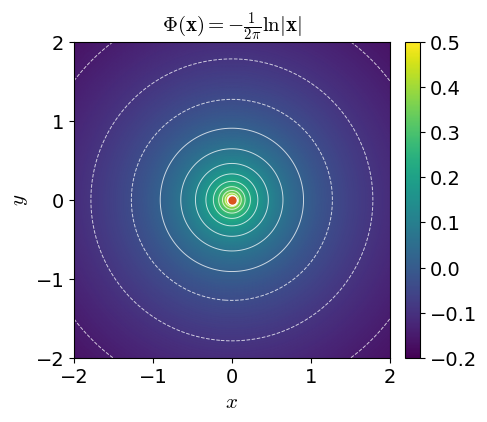

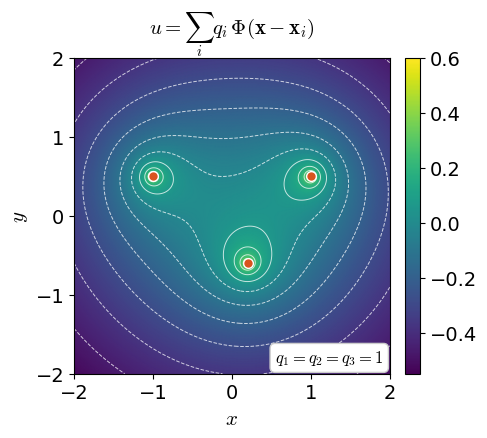

In [10]:
for nombre, U, titulo, (vmin_p, vmax_p) in [("sol-fundamental-lap", Phi_g, r"$\Phi(\mathbf{x}) = -\frac{1}{2\pi}\ln|\mathbf{x}|$", (-0.2, 0.5)), ("superposicion", u_sup, r"$u = \sum_i q_i\,\Phi(\mathbf{x} - \mathbf{x}_i)$", (-0.55, 0.6))]:
    with fuente(15):
        fig, ax = plt.subplots(figsize=(4.8, 4.1))
        im = mapa(ax, xp, xp, np.clip(U, vmin_p, vmax_p), vmin_p, vmax_p, niveles=12)
        ax.contour(xp, xp, U, levels=[0.8, 1.1, 1.5], colors="white", linewidths=0.7, alpha=0.75)   # niveles por encima de vmax: la singularidad
        for q, xi, yi in (cargas if nombre == "superposicion" else [(1, 0, 0)]):
            ax.plot(xi, yi, "o", color=COLORES["modelo"], ms=7, mec="white", zorder=5)
        ax.set_xticks([-2, -1, 0, 1, 2]); ax.set_yticks([-2, -1, 0, 1, 2]); ax.set_title(titulo)
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if nombre == "superposicion": estilo.parametros(ax, "$q_1 = q_2 = q_3 = 1$", loc="lower right", fontsize=12)
        if GUARDAR: estilo.guardar(fig, nombre)

**La convolución $u = \Phi * f$ suaviza.** Para una fuente $f$ cualquiera, $u(\mathbf x) = \int\Phi(\mathbf x - \mathbf y)f(\mathbf y)\,d\mathbf y$ resuelve $-\Delta u = f$ en todo el plano. **Figura `convolucion`**: la fuente del texto, una campana $f_0 = 1.5\,e^{-|\mathbf x|^2/2}$ más ruido blanco de desviación $0.5$ en cada celda de la grilla de $[-5,5]^2$, y $u = \Phi * f$ calculada como convolución discreta (con `scipy.signal.fftconvolve`; el valor de $\Phi$ en la celda del origen se reemplaza por su promedio sobre la celda). Dos verificaciones: para la parte radial $f_0$ la ecuación se integra a mano, $u_0'(r) = -\frac{1}{r}\int_0^r f_0(s)\,s\,ds = -1.5\,\frac{1 - e^{-r^2/2}}{r}$, y $\Phi * f_0$ coincide con $u_0$ salvo una constante; y el ruido, que en $f$ domina la variación entre celdas vecinas, en $u$ contribuye menos del $1\%$ de esa variación (los modos de alta frecuencia se dividen por $\lambda$ grande, como dice el texto en la sección siguiente).

In [11]:
N_c = 121; xc_ = np.linspace(-5, 5, N_c); hc = xc_[1] - xc_[0]
Xc, Yc = np.meshgrid(xc_, xc_); Rc = np.hypot(Xc, Yc)
A_c = 1.5
f0 = A_c * np.exp(-Rc ** 2 / 2)
ruido = 0.5 * rng.normal(size=f0.shape)
f_r = f0 + ruido
dk = hc * np.arange(-(N_c - 1), N_c)                                        # desplazamientos del núcleo
DX, DY = np.meshgrid(dk, dk)
with np.errstate(divide="ignore"):
    nucleo = Phi(DX, DY)
nucleo[N_c - 1, N_c - 1] = -(np.log(hc / np.sqrt(np.pi)) - 0.5) / (2 * np.pi)    # promedio de Phi sobre la celda del origen (disco de igual área)
conv = lambda F: fftconvolve(F, nucleo, mode="same") * hc ** 2
u_0, u_r = conv(f0), conv(f_r)

# parte radial: u_0'(r) = -A (1 - e^{-r^2/2})/r, integrada desde 0 con la regla del trapecio
rr = np.linspace(1e-6, 8, 4001); du0 = -A_c * (1 - np.exp(-rr ** 2 / 2)) / rr
u0_rad = np.concatenate([[0], np.cumsum(0.5 * (du0[1:] + du0[:-1]) * np.diff(rr))])
dif = u_0 - np.interp(Rc, rr, u0_rad)
print(f"Phi * f0 - u0_radial: media {dif.mean():.4f}, variación máx - mín {np.ptp(dif):.1e} (constante: la solución de -Delta u = f0 está definida salvo constante)")
print(f"residuo -Delta_h (Phi * f0) - f0 en el interior: máx {np.abs(-laplaciano_h(u_0, hc) - f0[1:-1, 1:-1]).max():.1e}  (máx f0 = {A_c})")
rug = lambda F: np.abs(np.diff(F, axis=1)).mean()
print(f"ruido en f: desviación {ruido.std():.3f} (señal máx {A_c}); variación media entre celdas vecinas: f {rug(f_r):.3f}, f0 {rug(f0):.3f} -> u {rug(u_r):.4f}, Phi*f0 {rug(u_0):.4f}")
print(f"parte del ruido en u, Phi * ruido: desviación {(u_r - u_0).std():.3f} (es una función suave, no ruido); rango de u: {u_r.min():.2f} .. {u_r.max():.2f}")

Phi * f0 - u0_radial: media -0.0870, variación máx - mín 3.9e-04 (constante: la solución de -Delta u = f0 está definida salvo constante)
residuo -Delta_h (Phi * f0) - f0 en el interior: máx 2.1e-03  (máx f0 = 1.5)
ruido en f: desviación 0.498 (señal máx 1.5); variación media entre celdas vecinas: f 0.568, f0 0.006 -> u 0.0223, Phi*f0 0.0219
parte del ruido en u, Phi * ruido: desviación 0.025 (es una función suave, no ruido); rango de u: -3.20 .. -0.27


**Figura `convolucion`**: $f$ y $u = \Phi * f$ como mapas de color. Los dos paneles tienen escalas distintas porque $f$ y $u$ son magnitudes distintas (y $u$ es negativa: $\Phi$ está definida salvo constante y vale $-\frac{1}{2\pi}\ln|\mathbf x| < 0$ para $|\mathbf x| > 1$).

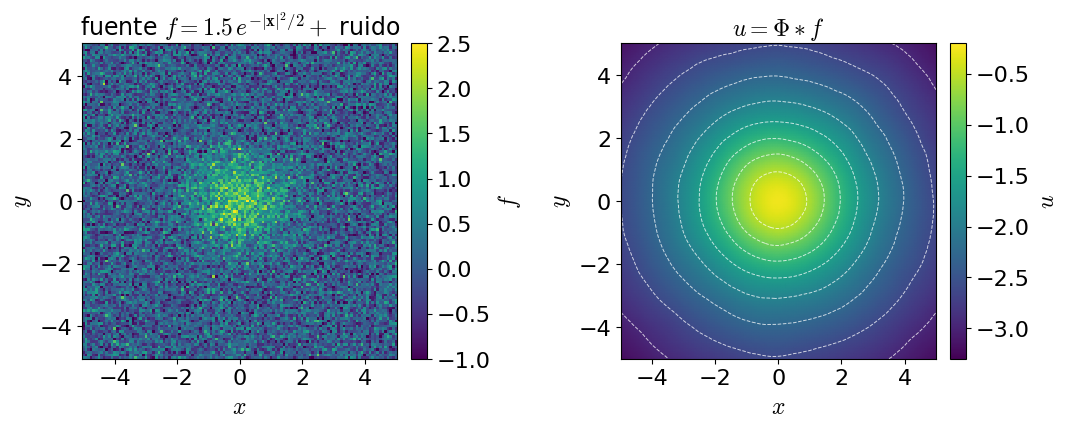

In [12]:
with fuente(17):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
    im1 = mapa(ax1, xc_, xc_, f_r, -1, 2.5, niveles=0, suave=False, etiqueta="fuente $f = 1.5\\,e^{-|\\mathbf{x}|^2/2} +$ ruido")
    im2 = mapa(ax2, xc_, xc_, u_r, np.floor(u_r.min() * 10) / 10, np.ceil(u_r.max() * 10) / 10, niveles=8, etiqueta="$u = \\Phi * f$")
    for ax, im, lab in [(ax1, im1, "$f$"), (ax2, im2, "$u$")]:
        ax.set_xticks([-4, -2, 0, 2, 4]); ax.set_yticks([-4, -2, 0, 2, 4]); cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label(lab)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "convolucion")

## 19.5 Series de Fourier en un rectángulo

En $\Omega = (0,L)\times(0,H)$ las funciones $\phi_{k\ell} = \sin\frac{k\pi x}{L}\sin\frac{\ell\pi y}{H}$ son autofunciones de $-\Delta$ con autovalores $\lambda_{k\ell} = (k\pi/L)^2 + (\ell\pi/H)^2$, y la solución de $-\Delta u = f$, $u = 0$ en el borde, es $u = \sum u_{k\ell}\phi_{k\ell}$ con $u_{k\ell} = f_{k\ell}/\lambda_{k\ell}$. El ejemplo del texto: $\Omega = (0,1)^2$ y $f(x,y) = -x\,e^{x+y}$, truncando a $k,\ell \le 20$. Como $f = (-xe^x)\,(e^y)$ es un producto, $f_{k\ell} = 4\,a_k b_\ell$ con integrales unidimensionales (`scipy.integrate.quad`). Verificamos: (i) la serie con $20$ modos contra la solución de cinco puntos con $h = 1/200$ (y contra la serie con $100$ modos); (ii) el residuo $-\Delta_h u_{20} - f$: la serie de $u$ converge rápido (los $u_{k\ell}$ decaen como $f_{k\ell}/(k^2 + \ell^2)$) pero la de $f$ no, porque $f \ne 0$ en el borde, así que $-\Delta u_{20} = f_{20}$ difiere de $f$ en $O(1)$ (hasta $7$ junto al borde, con oscilaciones de Gibbs que se propagan hacia adentro): la solución truncada es buena aunque la fuente truncada no lo sea; (iii) $u < 0$ en todo $\Omega$, como pide el principio del máximo con $f \le 0$ (y $\max u = 0$ en el borde). El mínimo, $\simeq -0.130$, está en $(0.67, 0.59)$, corrido hacia la esquina $(1,1)$ donde $f$ es más negativa.

*Nota sobre el texto*: el caption de la figura dice "$\Delta u = f$" y "20 nodos"; la ecuación resuelta es $-\Delta u = f$ (con $\Delta u = f$ y $f<0$ la solución sería positiva) y son 20 modos.

In [13]:
f_pf = lambda x, y: -x * np.exp(x + y)
a_k = lambda k: quad(lambda x: -x * np.exp(x) * np.sin(k * np.pi * x), 0, 1)[0]
b_l = lambda l: quad(lambda y: np.exp(y) * np.sin(l * np.pi * y), 0, 1)[0]

def u_fourier(x, y, K):
    '''Serie de Fourier truncada (k, l <= K) de la solución de -Delta u = f en (0,1)^2 con u = 0 en el borde; x, y arrays 1D (grilla).'''
    k = np.arange(1, K + 1); a = np.array([a_k(kk) for kk in k]); b = np.array([b_l(ll) for ll in k])
    lam = (k[:, None] ** 2 + k[None, :] ** 2) * np.pi ** 2                         # lambda_{kl} = (k pi)^2 + (l pi)^2
    U_kl = 4 * a[:, None] * b[None, :] / lam                                       # u_{kl} = f_{kl} / lambda_{kl}
    Sx = np.sin(np.pi * np.outer(k, x)); Sy = np.sin(np.pi * np.outer(k, y))       # (K, nx), (K, ny)
    return Sy.T @ U_kl.T @ Sx                                                       # u[i, j] = sum_{k,l} U_kl sin(k pi x_j) sin(l pi y_i)

n_pf = 200; h_pf = 1 / n_pf
xpf = np.linspace(0, 1, n_pf + 1); Xpf, Ypf = np.meshgrid(xpf, xpf)
u20, u100 = u_fourier(xpf, xpf, 20), u_fourier(xpf, xpf, 100)
u_dif = numerico.poisson_cinco_puntos(f_pf(Xpf, Ypf), np.zeros_like(Xpf), h_pf)
imin = np.unravel_index(u20.argmin(), u20.shape)
print(f"20 modos: mín u = {u20.min():.5f} en (x, y) = ({xpf[imin[1]]:.3f}, {xpf[imin[0]]:.3f}); máx u = {u20.max():.1e} (el borde); u < 0 en el interior: {np.all(u20[1:-1, 1:-1] < 0)}")
print(f"máx |u_20 - u_100| = {np.abs(u20 - u100).max():.1e};  máx |u_20 - cinco puntos (h = 1/{n_pf})| = {np.abs(u20 - u_dif).max():.1e};  máx |u_100 - cinco puntos| = {np.abs(u100 - u_dif).max():.1e}")
res20 = -laplaciano_h(u20, h_pf) - f_pf(Xpf, Ypf)[1:-1, 1:-1]
interior = (Xpf[1:-1, 1:-1] > 0.1) & (Xpf[1:-1, 1:-1] < 0.9) & (Ypf[1:-1, 1:-1] > 0.1) & (Ypf[1:-1, 1:-1] < 0.9)
print(f"residuo -Delta_h u_20 - f: máx {np.abs(res20).max():.2f} (junto al borde, donde f no se anula: f(1,1) = {f_pf(1, 1):.2f}), máx en [0.1, 0.9]^2: {np.abs(res20[interior]).max():.3f}, cuadrático medio global {np.sqrt(np.mean(res20 ** 2)):.3f}")
res_dif = -laplaciano_h(u_dif, h_pf) - f_pf(Xpf, Ypf)[1:-1, 1:-1]
print(f"residuo de la solución de cinco puntos (control): {np.abs(res_dif).max():.1e}")

20 modos: mín u = -0.12993 en (x, y) = (0.670, 0.585); máx u = 0.0e+00 (el borde); u < 0 en el interior: True
máx |u_20 - u_100| = 5.2e-04;  máx |u_20 - cinco puntos (h = 1/200)| = 5.2e-04;  máx |u_100 - cinco puntos| = 2.2e-05
residuo -Delta_h u_20 - f: máx 7.00 (junto al borde, donde f no se anula: f(1,1) = -7.39), máx en [0.1, 0.9]^2: 1.042, cuadrático medio global 0.527
residuo de la solución de cinco puntos (control): 2.0e-11


**Figura `poisson-fourier`**: la solución con $20$ modos como mapa de color con contornos, con el mínimo marcado (antes era una superficie 3D).

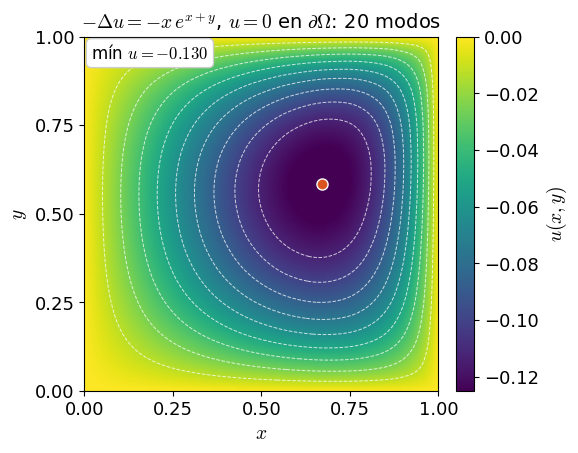

In [14]:
fig, ax = plt.subplots(figsize=(5.8, 4.6))
im = mapa(ax, xpf, xpf, u20, -0.125, 0, niveles=9)
ax.plot(xpf[imin[1]], xpf[imin[0]], "o", color=COLORES["modelo"], ms=8, mec="white")
ax.set_xticks([0, 0.25, 0.5, 0.75, 1]); ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.set_title(r"$-\Delta u = -x\,e^{x+y}$, $u = 0$ en $\partial\Omega$: 20 modos", fontsize=14)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label("$u(x, y)$")
estilo.parametros(ax, f"mín $u = {u20.min():.3f}$", loc="upper left", fontsize=12)
if GUARDAR: estilo.guardar(fig, "poisson-fourier")

## Para experimentar

1. En el juego, cambiá las probabilidades de salto (por ejemplo, $0.3$ a la derecha y $0.2$ a la izquierda): la ecuación de promedios deja de ser simétrica. Escribí la ecuación discreta que cumple el valor esperado, resolvela como sistema lineal y compará con Monte Carlo. ¿Qué ecuación en derivadas parciales aparece en el límite $h\to0$ (fijate qué pasa con el término de primer orden del desarrollo de Taylor)?
2. Agregá al juego un cobro de $h^2 f(x,y)/4$ en cada paso y verificá con Monte Carlo que el valor esperado resuelve $-\Delta u = f$ (compará con `poisson_cinco_puntos`). ¿Por qué el factor $h^2/4$?
3. Repetí el principio del máximo con condiciones de Neumann en dos lados (aislados) y Dirichlet en los otros dos: ¿siguen estando el máximo y el mínimo en la parte Dirichlet del borde? Y con una fuente $f$ que cambia de signo, buscá un ejemplo en que el máximo esté en el interior.
4. En el rectángulo, calculá con la serie de Fourier la solución para $f = 1$ y compará el valor en el centro con el $0.07367$ del capítulo anterior; después probá $f = \sin(3\pi x)\sin(3\pi y)$, para la que la serie tiene un solo término, y medí el error de la solución de cinco puntos en función de $h$ (debería ser $O(h^2)$).